<a href="https://colab.research.google.com/github/rmadatt/ADLAB/blob/main/YTChannel_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1019/3464610884.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_views, x="views", y="title", ax=axes[0, 0], palette="Blues_r")


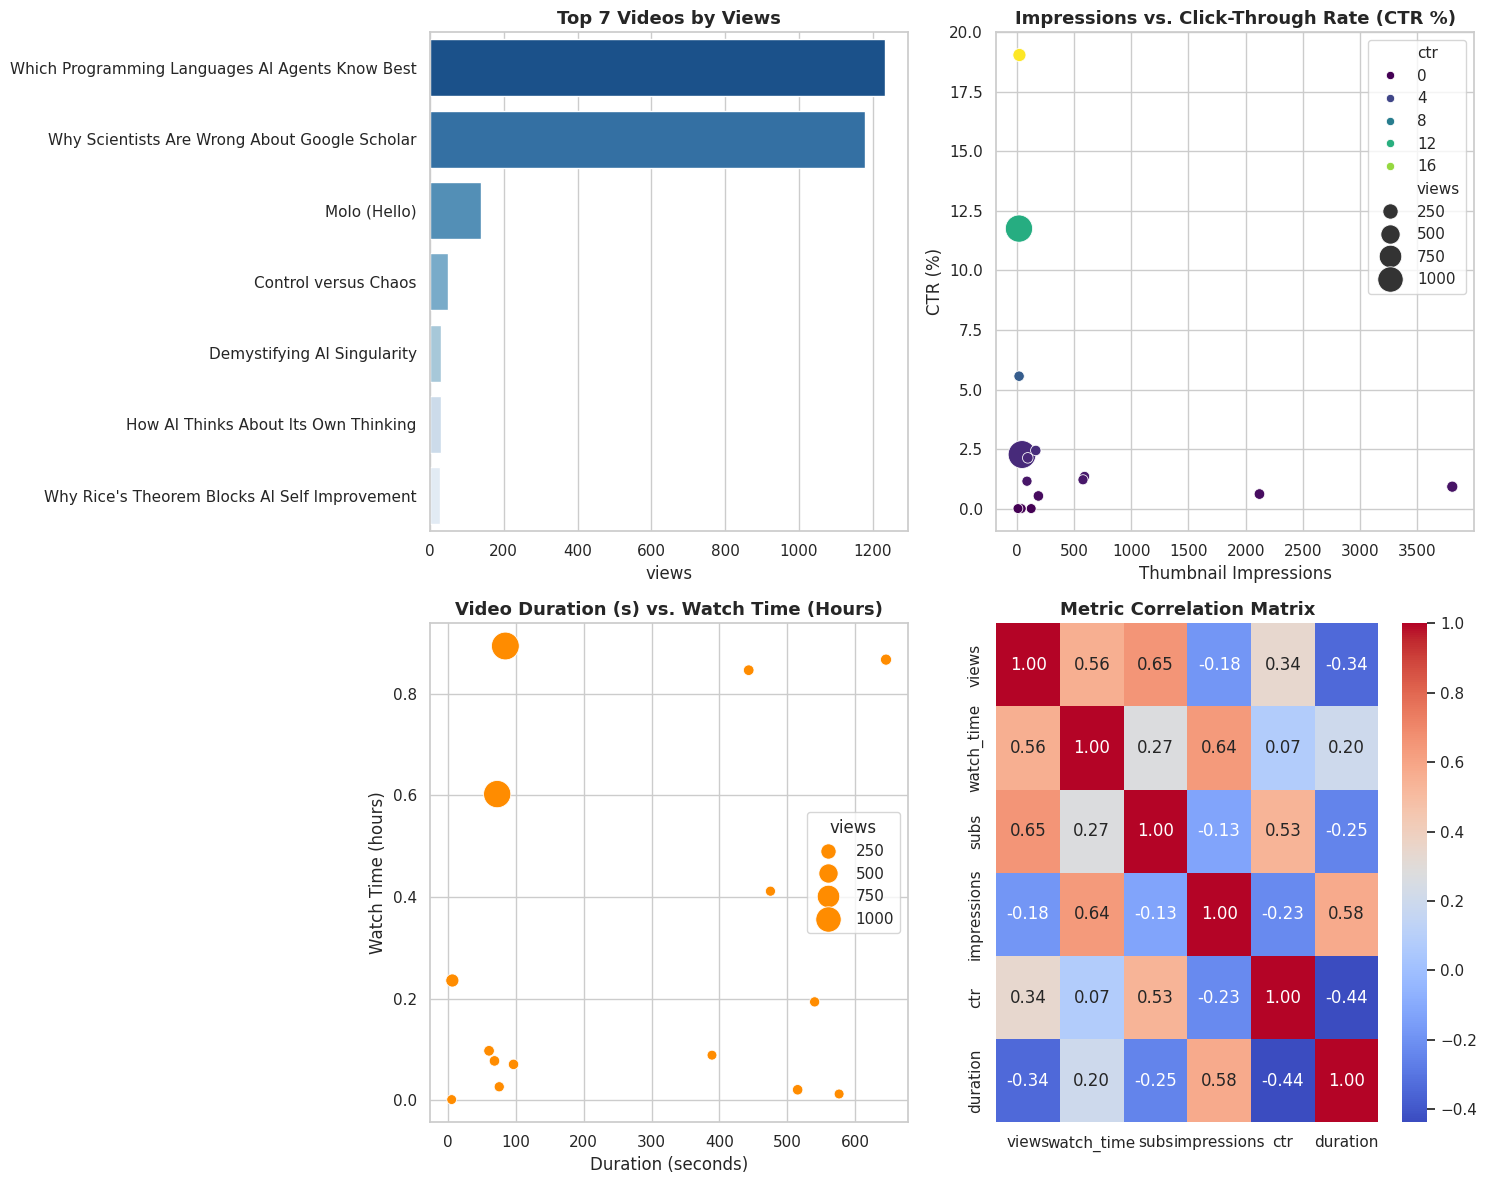

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load YouTube Analytics Data
data = [
    {"title": "Which Programming Languages AI Agents Know Best", "views": 1233, "watch_time": 0.8942, "subs": 0, "impressions": 44, "ctr": 2.27, "duration": 85},
    {"title": "Why Scientists Are Wrong About Google Scholar", "views": 1178, "watch_time": 0.6027, "subs": 17, "impressions": 17, "ctr": 11.76, "duration": 73},
    {"title": "Molo (Hello)", "views": 138, "watch_time": 0.2358, "subs": 2, "impressions": 21, "ctr": 19.05, "duration": 7},
    {"title": "Control versus Chaos", "views": 50, "watch_time": 0.8674, "subs": 0, "impressions": 3808, "ctr": 0.92, "duration": 645},
    {"title": "Demystifying AI Singularity", "views": 30, "watch_time": 0.8466, "subs": 1, "impressions": 2121, "ctr": 0.61, "duration": 443},
    {"title": "How AI Thinks About Its Own Thinking", "views": 30, "watch_time": 0.0974, "subs": 0, "impressions": 94, "ctr": 2.13, "duration": 61},
    {"title": "Why Rice's Theorem Blocks AI Self Improvement", "views": 26, "watch_time": 0.0775, "subs": 0, "impressions": 187, "ctr": 0.53, "duration": 69},
    {"title": "The Architects of AI", "views": 24, "watch_time": 0.0207, "subs": 0, "impressions": 164, "ctr": 2.44, "duration": 515},
    {"title": "How CPUs and GPUs Differ", "views": 22, "watch_time": 0.0707, "subs": 0, "impressions": 18, "ctr": 5.56, "duration": 97},
    {"title": "Why AGI Theories Break Code", "views": 14, "watch_time": 0.1937, "subs": 0, "impressions": 591, "ctr": 1.35, "duration": 540},
    {"title": "Ranking the Architects Who Built Modern AI", "views": 13, "watch_time": 0.0266, "subs": 0, "impressions": 87, "ctr": 1.15, "duration": 76},
    {"title": "AI Singularity Hype vs Fact", "views": 11, "watch_time": 0.4116, "subs": 0, "impressions": 577, "ctr": 1.21, "duration": 475},
    {"title": "Unveiling NVIDIA CUDA", "views": 3, "watch_time": 0.0124, "subs": 0, "impressions": 124, "ctr": 0.00, "duration": 576},
    {"title": "Why AI Currently Fails at C++", "views": 2, "watch_time": 0.0888, "subs": 0, "impressions": 37, "ctr": 0.00, "duration": 389},
    {"title": "My Old Laptop Revival", "views": 1, "watch_time": 0.0014, "subs": 0, "impressions": 8, "ctr": 0.00, "duration": 6}
]

df = pd.DataFrame(data)

# 2. Build Multi-Panel Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Top Videos by Views
top_views = df.sort_values(by="views", ascending=False).head(7)
sns.barplot(data=top_views, x="views", y="title", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Top 7 Videos by Views", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("")

# Impressions vs. CTR
sns.scatterplot(
    data=df, x="impressions", y="ctr", size="views", hue="ctr",
    sizes=(50, 400), ax=axes[0, 1], palette="viridis"
)
axes[0, 1].set_title("Impressions vs. Click-Through Rate (CTR %)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Thumbnail Impressions")
axes[0, 1].set_ylabel("CTR (%)")

# Duration vs. Watch Time
sns.scatterplot(
    data=df, x="duration", y="watch_time", size="views",
    sizes=(50, 400), ax=axes[1, 0], color="darkorange"
)
axes[1, 0].set_title("Video Duration (s) vs. Watch Time (Hours)", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Duration (seconds)")
axes[1, 0].set_ylabel("Watch Time (hours)")

# Metric Correlation Heatmap
numeric_df = df[["views", "watch_time", "subs", "impressions", "ctr", "duration"]]
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Metric Correlation Matrix", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [2]:
import plotly.express as px

fig = px.scatter(
    df,
    x="impressions",
    y="ctr",
    size="views",
    color="watch_time",
    hover_name="title",
    hover_data=["views", "subs", "duration"],
    title="YouTube Content Efficiency: Impressions vs. CTR",
    labels={
        "impressions": "Thumbnail Impressions",
        "ctr": "Click-Through Rate (%)",
        "watch_time": "Watch Time (hrs)"
    },
    template="plotly_white"
)

fig.show()